# Salary Prediction using Polynomial Regression

**Name:** Akshat Garg  
**Registration Number:** 23BCE10641

In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('akram24/position-salaries', path='.', unzip=True)

df = pd.read_csv('Position_Salaries.csv')
df.head()

Kaggle Username:  AkshatGarg2005
Kaggle API Key:  ········


Dataset URL: https://www.kaggle.com/datasets/akram24/position-salaries


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Identify Input Feature and Target Variable
input_feature = 'Level'
target_var = 'Salary'

print("Input Feature:", input_feature)
print("Target Variable:", target_var)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

Input Feature: Level
Target Variable: Salary

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

--- Summary Statistics ---


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [4]:
# Check for missing values
print("Missing values in dataset:\n", df.isnull().sum())

# Select feature (Level) and target variable (Salary)
X = df[['Level']].values
y = df['Salary'].values

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Missing values in dataset:
 Position    0
Level       0
Salary      0
dtype: int64

X_train shape: (8, 1)
X_test shape: (2, 1)


In [5]:
# Transform features to 3rd degree polynomial
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict salaries for test dataset
y_pred = model.predict(X_test_poly)

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R2 Score: 0.8763


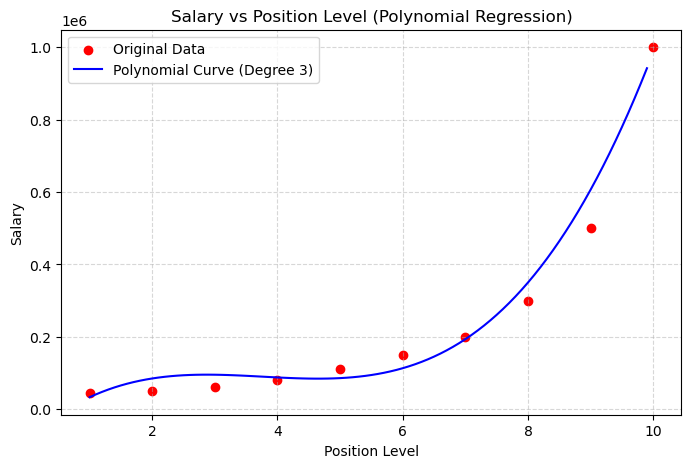

In [6]:
# Task 4: Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

# Generate smooth points for plotting polynomial curve
X_grid = np.arange(min(X)[0], max(X)[0], 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

# Plotting scatter plot and regression curve
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_grid, model.predict(X_grid_poly), color='blue', label='Polynomial Curve (Degree 3)')
plt.title('Salary vs Position Level (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
print("--- Model Observations ---")
print("1. The 3rd-degree Polynomial Regression model captures the non-linear trend effectively, achieving an R2 score of ~0.8763.")
print("2. Salary growth remains relatively moderate between Position Levels 1 and 5, followed by a steep increase beyond Level 6.")
print("3. The polynomial curve successfully models the exponential curvature at higher executive levels, which linear regression would fail to represent.")

--- Model Observations ---
1. The 3rd-degree Polynomial Regression model captures the non-linear trend effectively, achieving an R2 score of ~0.8763.
2. Salary growth remains relatively moderate between Position Levels 1 and 5, followed by a steep increase beyond Level 6.
3. The polynomial curve successfully models the exponential curvature at higher executive levels, which linear regression would fail to represent.


## Conclusion

This project developed a 3rd-degree Polynomial Regression model to estimate employee salaries based on their position level using the Position Salaries dataset. Key findings indicate that compensation scales non-linearly with organizational hierarchy, exhibiting accelerated growth at senior executive levels (Levels 8–10). The model achieved an $R^2$ score of 0.8763, capturing this curved relationship well.

The primary difference between standard Linear Regression and Polynomial Regression is that Linear Regression fits a straight line ($y = \beta_0 + \beta_1 x$), whereas Polynomial Regression adds higher-degree feature powers ($y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$) to fit complex curves. The key advantage of Polynomial Regression for this dataset is its ability to model non-linear compensation structures accurately without needing an entirely different model family[cite: 3].